# 42172 Introduction to Artificial Intelligence - AT1 Example I
## A Sydney inspection route using simulated annealing and a genetic algorithm

**Name:** Aditya Maurya  
**Portfolio copy**

This notebook compares two search methods on the same route-planning problem. I kept the code deliberately small and used ordinary Python, NumPy, pandas and Matplotlib so that each step can be read and rerun in Google Colab.


## 1. Setup and data

The task is to start at Sydney Town Hall, visit the other 19 places once, and return to Town Hall. I recorded this coordinate table from Google Maps for this project. It is not copied from a Kaggle competition or from a dataset supplied with a finished solution. The UTS Tower row is kept separate until the final new-data check.


In [1]:
import math
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

LOCATIONS = [('Sydney Town Hall (depot)', -33.873157, 151.206115), ('Queen Victoria Building', -33.871843, 151.206851), ('Hyde Park North', -33.871176, 151.21144), ("St Mary's Cathedral", -33.871263, 151.213253), ('Art Gallery of NSW', -33.868821, 151.217392), ('Royal Botanic Garden', -33.864167, 151.216667), ("Mrs Macquarie's Chair", -33.859289, 151.222311), ('Sydney Opera House', -33.856784, 151.215297), ('Circular Quay', -33.861052, 151.21039), ('Museum of Contemporary Art', -33.85986, 151.209029), ('The Rocks Discovery Museum', -33.859992, 151.208817), ('Sydney Observatory', -33.85954, 151.204692), ('Barangaroo Reserve', -33.857213, 151.201708), ('Wynyard Park', -33.865873, 151.205352), ('Martin Place', -33.867974, 151.210642), ('Pitt Street Mall', -33.86963, 151.208585), ('Darling Harbour', -33.87488, 151.20082), ('Chinese Garden of Friendship', -33.876436, 151.202163), ('ICC Sydney', -33.875899, 151.199522), ('Australian Museum', -33.874279, 151.21324)]
NEW_LOCATION = ('UTS Tower (new site)', -33.88336, 151.200541)

frame = pd.DataFrame(LOCATIONS, columns=['location', 'latitude', 'longitude'])
frame


,location,latitude,longitude
0,Sydney Town Hall (depot),-33.873157,151.206115
1,Queen Victoria Building,-33.871843,151.206851
2,Hyde Park North,-33.871176,151.211440
3,St Mary's Cathedral,-33.871263,151.213253
4,Art Gallery of NSW,-33.868821,151.217392
5,Royal Botanic Garden,-33.864167,151.216667
6,Mrs Macquarie's Chair,-33.859289,151.222311
7,Sydney Opera House,-33.856784,151.215297
8,Circular Quay,-33.861052,151.210390
9,Museum of Contemporary Art,-33.859860,151.209029


## 2. Distance calculation and basic checks

Latitude and longitude are converted to kilometres with the Haversine formula. This gives a clear and reproducible distance measure, although it is only an approximation of real walking distance. Both algorithms use this exact same matrix.


In [2]:
EARTH_RADIUS_KM = 6371.0088

def make_distance_matrix(data):
    points = np.radians(data[['latitude', 'longitude']].to_numpy())
    lat = points[:, 0][:, None]
    lon = points[:, 1][:, None]
    dlat = lat.T - lat
    dlon = lon.T - lon
    a = np.sin(dlat / 2) ** 2 + np.cos(lat) * np.cos(lat.T) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def route_distance(route, distances):
    route = np.asarray(route, dtype=int)
    return float(distances[route, np.roll(route, -1)].sum())

def route_is_valid(route, number_of_places):
    return route[0] == 0 and sorted(route) == list(range(number_of_places))

distances = make_distance_matrix(frame)
print('Matrix shape:', distances.shape)
print('Symmetric:', np.allclose(distances, distances.T))
print('Zero diagonal:', np.allclose(np.diag(distances), 0))
print('Missing values:', int(frame.isna().sum().sum()))


Matrix shape: (20, 20)
Symmetric: True
Zero diagonal: True
Missing values: 0


## 3. Looking at the locations

I plotted the points before optimisation to check that the coordinates look reasonable. Location 0 is the Town Hall depot.


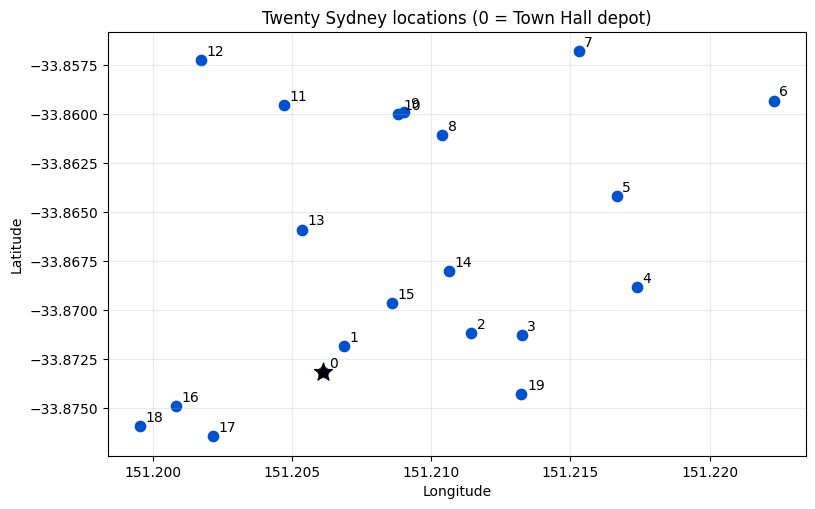

In [3]:
plt.figure(figsize=(9, 5.5))
plt.scatter(frame.longitude, frame.latitude, s=55, color='#0052CC')
for i, row in frame.iterrows():
    plt.annotate(str(i), (row.longitude, row.latitude), xytext=(4, 3), textcoords='offset points')
plt.scatter(frame.longitude.iloc[0], frame.latitude.iloc[0], marker='*', s=180, color='black')
plt.title('Twenty Sydney locations (0 = Town Hall depot)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(alpha=0.25)
plt.show()


## 4. A simple baseline

Nearest neighbour always visits the closest unvisited place. It is not one of my two assessed AI solutions; it is only a simple reference point. The route is valid, but each local choice can make the final part of the trip longer.


In [4]:
def nearest_neighbour(distances):
    route = [0]
    unvisited = set(range(1, len(distances)))
    while unvisited:
        next_place = min(unvisited, key=lambda j: distances[route[-1], j])
        route.append(next_place)
        unvisited.remove(next_place)
    return route

baseline_route = nearest_neighbour(distances)
baseline_km = route_distance(baseline_route, distances)
print(f'Baseline distance: {baseline_km:.3f} km')
print('Valid route:', route_is_valid(baseline_route, len(frame)))


Baseline distance: 12.344 km
Valid route: True


## 5. Solution 1 - simulated annealing

Simulated annealing keeps one route at a time. I make a neighbouring route by reversing a random section. A shorter route is accepted. A longer route can also be accepted early in the run, which helps the search move out of a local minimum. As the temperature cools, those worse moves become less likely.


In [5]:
def starting_route(distances, rng):
    route = nearest_neighbour(distances)
    for _ in range(3):
        i, j = sorted(rng.choice(range(1, len(route)), 2, replace=False))
        route[i:j + 1] = route[i:j + 1][::-1]
    return route

def simulated_annealing(distances, seed, temperature=0.75, cooling=0.997, iterations=5000):
    rng = np.random.default_rng(seed)
    current = starting_route(distances, rng)
    current_cost = route_distance(current, distances)
    best, best_cost = current.copy(), current_cost
    history = []

    for step in range(iterations):
        i, j = sorted(rng.choice(range(1, len(current)), 2, replace=False))
        candidate = current.copy()
        candidate[i:j + 1] = candidate[i:j + 1][::-1]
        candidate_cost = route_distance(candidate, distances)
        change = candidate_cost - current_cost

        if change < 0 or rng.random() < math.exp(-change / max(temperature, 1e-12)):
            current, current_cost = candidate, candidate_cost
            if current_cost < best_cost:
                best, best_cost = current.copy(), current_cost

        temperature = max(0.00001, temperature * cooling)
        if step % 25 == 0 or step == iterations - 1:
            history.append(best_cost)
    return best, best_cost, history

test_route, test_cost, _ = simulated_annealing(distances, seed=1)
print(f'SA test distance: {test_cost:.3f} km')
print('Valid route:', route_is_valid(test_route, len(frame)))


SA test distance: 8.912 km
Valid route: True


## 6. Solution 2 - genetic algorithm

The genetic algorithm works with many routes. Tournament selection favours shorter parents, order crossover combines their visit order without repeating a place, and mutation reverses part of a route. I also keep a few of the best routes unchanged in each generation. These choices make every chromosome a valid route.


In [6]:
def order_crossover(parent_a, parent_b, rng):
    a, b = parent_a[1:], parent_b[1:]
    left, right = sorted(rng.choice(len(a), 2, replace=False))
    middle = a[left:right + 1]
    remaining = [place for place in b if place not in middle]
    return [0] + remaining[:left] + middle + remaining[left:]

def mutate(route, rng, mutation_rate):
    child = route.copy()
    if rng.random() < mutation_rate:
        i, j = sorted(rng.choice(range(1, len(child)), 2, replace=False))
        child[i:j + 1] = child[i:j + 1][::-1]
    return child

def choose_parent(population, costs, rng, tournament_size=4):
    choices = rng.choice(len(population), tournament_size, replace=False)
    winner = choices[np.argmin(costs[choices])]
    return population[int(winner)]

def genetic_algorithm(distances, seed, population_size=80, generations=260,
                      mutation_rate=0.30, elite_size=4):
    rng = np.random.default_rng(seed)
    population = [nearest_neighbour(distances)]
    for _ in range(population_size - 1):
        population.append([0] + rng.permutation(range(1, len(distances))).tolist())

    best = population[0].copy()
    best_cost = route_distance(best, distances)
    history = []

    for _ in range(generations):
        costs = np.array([route_distance(route, distances) for route in population])
        order = np.argsort(costs)
        if costs[order[0]] < best_cost:
            best = population[int(order[0])].copy()
            best_cost = float(costs[order[0]])
        history.append(best_cost)

        next_population = [population[int(i)].copy() for i in order[:elite_size]]
        while len(next_population) < population_size:
            parent_a = choose_parent(population, costs, rng)
            parent_b = choose_parent(population, costs, rng)
            child = order_crossover(parent_a, parent_b, rng)
            next_population.append(mutate(child, rng, mutation_rate))
        population = next_population
    return best, best_cost, history

test_route, test_cost, _ = genetic_algorithm(distances, seed=1)
print(f'GA test distance: {test_cost:.3f} km')
print('Valid route:', route_is_valid(test_route, len(frame)))


GA test distance: 8.896 km
Valid route: True


## 7. Small parameter trial

I tested four settings for each method on five seeds before the main comparison. This kept parameter choice separate from the final 30 runs. The selected SA setting was temperature 0.75 and cooling 0.997. The selected GA used a population of 80 and mutation rate 0.30. I then increased the final search budget to 5,000 SA steps and 260 GA generations.


In [7]:
sa_trials = [(0.75, 0.995), (0.75, 0.997), (1.50, 0.995), (1.50, 0.997)]
ga_trials = [(80, 0.15), (80, 0.30), (120, 0.15), (120, 0.30)]
pilot_rows = []

for number, (temp, cool) in enumerate(sa_trials, 1):
    scores = [simulated_annealing(distances, seed, temp, cool, 3000)[1]
              for seed in range(100, 105)]
    pilot_rows.append(['SA', f'SA-{number}', np.mean(scores), np.std(scores, ddof=1), np.min(scores)])

for number, (pop_size, mutation_rate) in enumerate(ga_trials, 1):
    elite_size = max(4, pop_size // 20)
    scores = [genetic_algorithm(distances, seed, pop_size, 180, mutation_rate, elite_size)[1]
              for seed in range(100, 105)]
    pilot_rows.append(['GA', f'GA-{number}', np.mean(scores), np.std(scores, ddof=1), np.min(scores)])

pilot_results = pd.DataFrame(pilot_rows, columns=['method', 'setting', 'mean_km', 'sd_km', 'best_km'])
print(pilot_results.round(4).to_string(index=False))


method setting  mean_km  sd_km  best_km
    SA    SA-1   8.9361 0.0813   8.8959
    SA    SA-2   8.8959 0.0000   8.8959
    SA    SA-3   8.9904 0.1262   8.8959
    SA    SA-4   8.9423 0.0778   8.8959
    GA    GA-1   9.1238 0.4744   8.9116
    GA    GA-2   8.9116 0.0000   8.9116
    GA    GA-3   8.9116 0.0000   8.9116
    GA    GA-4   8.9116 0.0000   8.9116


## 8. Main comparison - 30 runs each

One random run would not be a fair comparison. I therefore ran each method 30 times using the same seed numbers. Distance is the main measure. I also recorded runtime, standard deviation and the percentage of runs within 1% of the best distance found by either method. “Best found” is used instead of “optimal” because these methods do not prove the global optimum.


In [8]:
settings = {
    'Simulated annealing': {'temperature': 0.75, 'cooling': 0.997, 'iterations': 5000},
    'Genetic algorithm': {'population_size': 80, 'generations': 260,
                          'mutation_rate': 0.30, 'elite_size': 4}
}
rows = []
best_runs = {}
for method in settings:
    for run_number, seed in enumerate(range(202600, 202630), 1):
        start = time.perf_counter()
        if method == 'Simulated annealing':
            route, cost, history = simulated_annealing(distances, seed, **settings[method])
        else:
            route, cost, history = genetic_algorithm(distances, seed, **settings[method])
        rows.append([method, run_number, seed, cost, time.perf_counter() - start])
        if method not in best_runs or cost < best_runs[method]['cost']:
            best_runs[method] = {'route': route, 'cost': cost, 'history': history, 'seed': seed}

results = pd.DataFrame(rows, columns=['method', 'run', 'seed', 'distance_km', 'runtime_s'])
pooled_best = results.distance_km.min()
summary = results.groupby('method').agg(
    best_km=('distance_km', 'min'), mean_km=('distance_km', 'mean'),
    median_km=('distance_km', 'median'), sd_km=('distance_km', 'std'),
    mean_time_s=('runtime_s', 'mean')).reset_index()
close_rates = results.assign(close=results.distance_km <= pooled_best * 1.01).groupby('method').close.mean() * 100
summary['within_1pct'] = summary['method'].map(close_rates)
summary['improvement_vs_baseline'] = 100 * (baseline_km - summary.mean_km) / baseline_km
display_summary = summary[['method', 'best_km', 'mean_km', 'sd_km',
                           'mean_time_s', 'within_1pct', 'improvement_vs_baseline']].copy()
display_summary['method'] = display_summary['method'].replace(
    {'Genetic algorithm': 'GA', 'Simulated annealing': 'SA'})
display_summary.columns = ['method', 'best', 'mean', 'sd', 'time_s', 'within_1%', 'improve_%']
print(display_summary.round(4).to_string(index=False))


method   best   mean     sd  time_s  within_1%  improve_%
    GA 8.8959 8.9111 0.0029  2.1396      100.0    27.8078
    SA 8.8959 8.9719 0.2058  0.3355       80.0    27.3153


## 9. Results in pictures

The distribution matters more than a single lucky run. The GA results are tightly grouped, while SA has several longer results. The convergence plot shows how the best result in each selected run improved over time; the horizontal scales are different because SA uses steps and GA uses generations.


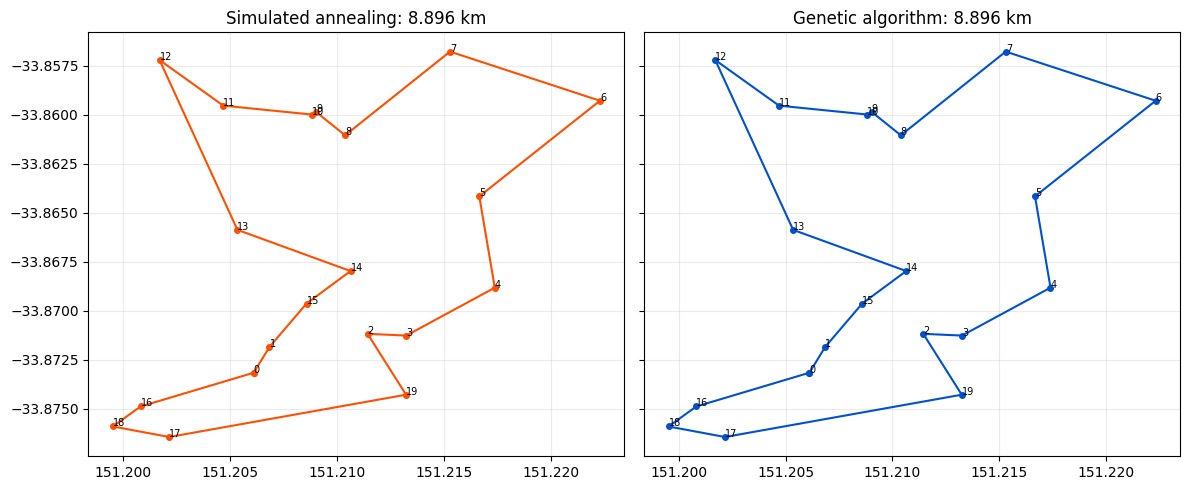

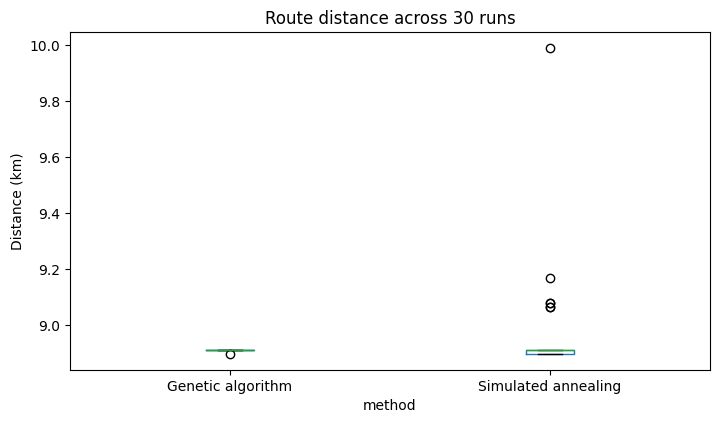

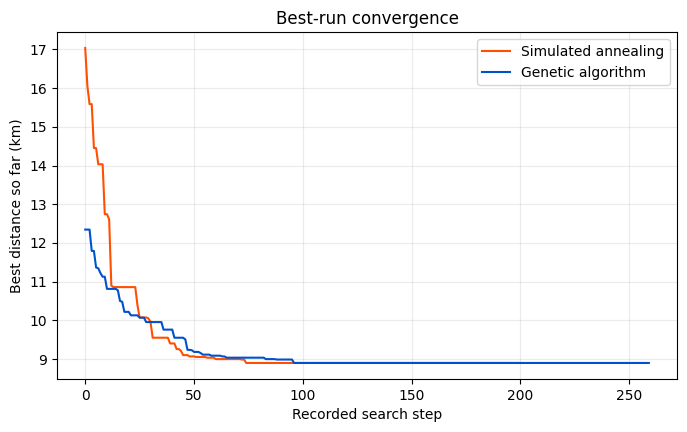

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
colours = {'Simulated annealing': '#FF4F00', 'Genetic algorithm': '#0052CC'}
for ax, method in zip(axes, settings):
    route = best_runs[method]['route'] + [0]
    ax.plot(frame.longitude.iloc[route], frame.latitude.iloc[route], '-o', ms=4, color=colours[method])
    for i, row in frame.iterrows():
        ax.annotate(str(i), (row.longitude, row.latitude), fontsize=7)
    ax.set_title(f"{method}: {best_runs[method]['cost']:.3f} km")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

results.boxplot(column='distance_km', by='method', figsize=(8, 4.5), grid=False)
plt.suptitle('')
plt.title('Route distance across 30 runs')
plt.ylabel('Distance (km)')
plt.show()

plt.figure(figsize=(8, 4.5))
for method, details in best_runs.items():
    plt.plot(details['history'], label=method, color=colours[method])
plt.xlabel('Recorded search step')
plt.ylabel('Best distance so far (km)')
plt.title('Best-run convergence')
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 10. Recommendation

Both methods reached the same best-found distance of 8.896 km. I recommend the genetic algorithm because its average was lower, its spread was much smaller, and every GA run finished within 1% of the best result. SA was much faster, so it would still be useful when a quick answer matters more than consistency. For this small daily-planning example, the GA's extra second is not important.


In [10]:
recommended = 'Genetic algorithm'
print('Recommended method:', recommended)
print('Best retained route:')
for step, place in enumerate(best_runs[recommended]['route'] + [0]):
    print(f'{step:02d}. {frame.location.iloc[place]}')


Recommended method: Genetic algorithm
Best retained route:
00. Sydney Town Hall (depot)
01. Darling Harbour
02. ICC Sydney
03. Chinese Garden of Friendship
04. Australian Museum
05. Hyde Park North
06. St Mary's Cathedral
07. Art Gallery of NSW
08. Royal Botanic Garden
09. Mrs Macquarie's Chair
10. Sydney Opera House
11. Circular Quay
12. Museum of Contemporary Art
13. The Rocks Discovery Museum
14. Sydney Observatory
15. Barangaroo Reserve
16. Wynyard Park
17. Martin Place
18. Pitt Street Mall
19. Queen Victoria Building
20. Sydney Town Hall (depot)


## 11. New-data comparison

I added UTS Tower as a 21st place and reran **both** search methods ten times without changing their selected parameters. The table reports best distance, mean distance, standard deviation and mean runtime. The maps show each method's best route, and the box plot shows variation across the ten runs. The black X is the new UTS Tower location.


New location: UTS Tower (new site)
method  best_km  mean_km  sd_km  mean_time_s
    GA  10.2799  10.2952 0.0485        3.378
    SA  10.1771  10.2448 0.0873        0.450


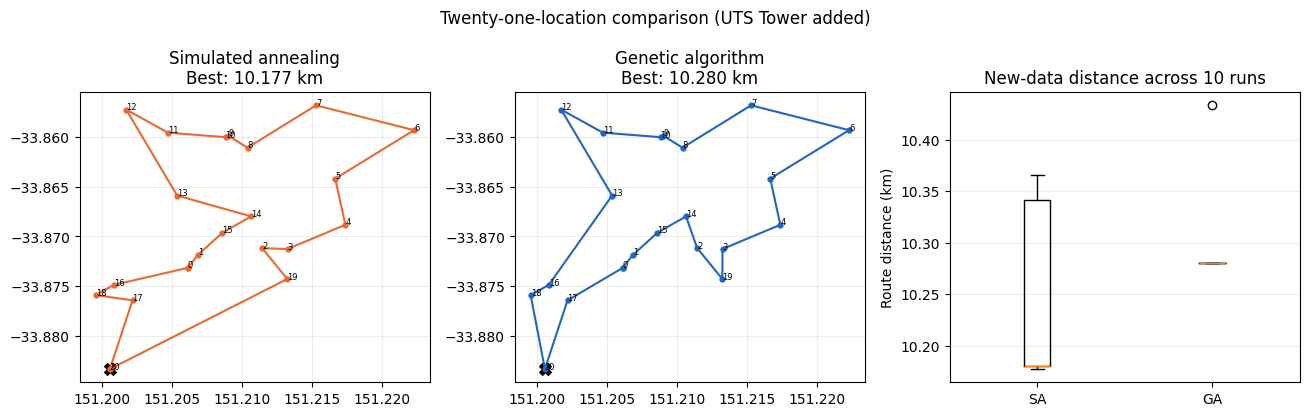

In [11]:
future_frame = pd.concat([
    frame,
    pd.DataFrame([NEW_LOCATION], columns=['location', 'latitude', 'longitude'])
], ignore_index=True)
future_distances = make_distance_matrix(future_frame)

future_rows = []
future_best_runs = {}
for method in settings:
    for run_number, seed in enumerate(range(9900, 9910), 1):
        start = time.perf_counter()
        if method == 'Simulated annealing':
            route, cost, history = simulated_annealing(
                future_distances, seed, **settings[method])
        else:
            route, cost, history = genetic_algorithm(
                future_distances, seed, **settings[method])
        runtime = time.perf_counter() - start
        future_rows.append([method, run_number, seed, cost, runtime])
        if method not in future_best_runs or cost < future_best_runs[method]['cost']:
            future_best_runs[method] = {
                'route': route, 'cost': cost, 'history': history, 'seed': seed}

future_results = pd.DataFrame(
    future_rows, columns=['method', 'run', 'seed', 'distance_km', 'runtime_s'])
future_summary = future_results.groupby('method').agg(
    best_km=('distance_km', 'min'), mean_km=('distance_km', 'mean'),
    sd_km=('distance_km', 'std'), mean_time_s=('runtime_s', 'mean')).reset_index()
future_summary['method'] = future_summary['method'].replace(
    {'Simulated annealing': 'SA', 'Genetic algorithm': 'GA'})
print('New location:', NEW_LOCATION[0])
print(future_summary.round(4).to_string(index=False))

colours = {'Simulated annealing': '#E86A33', 'Genetic algorithm': '#2166C1'}
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2))
for ax, method in zip(axes[:2], settings):
    route = future_best_runs[method]['route'] + [0]
    ax.plot(future_frame.longitude.iloc[route], future_frame.latitude.iloc[route],
            '-o', ms=3.5, color=colours[method])
    for i, row in future_frame.iterrows():
        ax.annotate(str(i), (row.longitude, row.latitude), fontsize=6)
    ax.scatter(future_frame.longitude.iloc[-1], future_frame.latitude.iloc[-1],
               marker='X', s=70, color='black')
    ax.set_title(f"{method}\nBest: {future_best_runs[method]['cost']:.3f} km")
    ax.grid(alpha=0.22)

plot_data = [future_results.loc[future_results.method == method, 'distance_km']
             for method in settings]
axes[2].boxplot(plot_data, tick_labels=['SA', 'GA'])
axes[2].set_title('New-data distance across 10 runs')
axes[2].set_ylabel('Route distance (km)')
axes[2].grid(axis='y', alpha=0.22)
fig.suptitle('Twenty-one-location comparison (UTS Tower added)')
plt.tight_layout()
plt.show()


## 12. Limits and final note

- Straight-line distance does not include streets, crossings, stairs, opening hours or time spent at each stop.
- The coordinates were typed manually and should be checked again before any real use.
- The best distance found in the experiment is not proof of the mathematical optimum.
- Only public-place coordinates are used; there is no personal or sensitive data.
- A real worker or planner should check the final route rather than follow it automatically.

Both search techniques also worked after UTS Tower was added. In this new case, SA produced the shorter mean route and was faster, while GA had the lower standard deviation. This means the original GA recommendation is not universal and should be checked again when the data change.
